# BTC Option Data Descriptive Diagnostics

This notebook documents the construction of the BTC option panels used in the empirical analysis and reproduces the descriptive figures used to motivate the filtering exercise. It is intended as a readable companion to the thesis data chapter rather than as a scratch notebook.

The workflow is:

1. load the raw Deribit option snapshot file,
2. apply the baseline maturity, moneyness, and quote-cap filters,
3. validate the timestamp-level forward proxy used by the filters,
4. inspect how representative panels are selected, and
5. generate the three descriptive plots for the retained sample.

The default cleaning and quote-selection settings follow the filtering scripts: maturities between 1 and 120 days, absolute log-moneyness at most 0.50, and at most 160 retained option quotes per timestamp.


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    return here.parent if here.name == 'notebooks' else here


PROJECT_ROOT = find_project_root()
RAW_CSV = Path(
    os.environ.get(
        'BTC_OPTIONS_SNAPSHOTS_CSV',
        PROJECT_ROOT / 'data' / 'raw' / 'btc_options_snapshots_5d.csv',
    )
).expanduser()
if not RAW_CSV.exists():
    raise FileNotFoundError(
        'Could not find the raw BTC option snapshot file. '
        'Place it at data/raw/btc_options_snapshots_5d.csv or set BTC_OPTIONS_SNAPSHOTS_CSV.'
    )

START_INDEX = 0
N_TIMESTAMPS = 400
MIN_MATURITY_DAYS = 1.0
MAX_MATURITY_DAYS = 120.0
MAX_ABS_LOG_MONEYNESS = 0.50
MAX_OPTIONS_PER_TIMESTAMP = 160

OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'chapter2_data_descriptive_plots'
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Raw CSV: {RAW_CSV}')
print(f'Figure output: {FIGURE_DIR}')

## 1. Load the Raw Data

The raw file is loaded here as `df`. At this point no cleaning, maturity filtering, moneyness filtering, or quote selection has been applied.


In [62]:
df = pd.read_csv(RAW_CSV)

print(f'Raw dataframe shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())
display(df.dtypes.rename('dtype').to_frame())

Raw dataframe shape: 1,661,368 rows x 17 columns


,capture_time_utc,instrument_name,expiry,time_to_expiry_years,strike,option_type,bid_price,ask_price,mid_price,mark_price,last_price,underlying_price,underlying_index,mark_iv,open_interest,volume,volume_usd
0,2026-05-26T13:25:12.749879+00:00,BTC-12JUN26-86000-C,2026-06-12T00:00:00+00:00,0.045043,86000.0,C,0.0017,0.0021,0.00190,0.001804,0.0020,76793.23,BTC-12JUN26,33.26,725.4,710.3,107683.31
1,2026-05-26T13:25:12.749879+00:00,BTC-5JUN26-66000-C,2026-06-05T00:00:00+00:00,0.025865,66000.0,C,0.1395,0.1430,0.14125,0.140976,0.1391,76767.93,BTC-5JUN26,46.72,0.1,0.1,1065.14
2,2026-05-26T13:25:12.749879+00:00,BTC-31JUL26-108000-P,2026-07-31T00:00:00+00:00,0.179290,108000.0,P,0.4000,0.4075,0.40375,0.403993,NaN,76999.76,BTC-31JUL26,39.12,0.0,0.0,0.00
3,2026-05-26T13:25:12.749879+00:00,BTC-25SEP26-30000-C,2026-09-25T00:00:00+00:00,0.332715,30000.0,C,0.6130,0.6145,0.61375,0.613696,0.5645,77358.57,BTC-25SEP26,75.95,97.8,0.0,0.00
4,2026-05-26T13:25:12.749879+00:00,BTC-31JUL26-73000-C,2026-07-31T00:00:00+00:00,0.179290,73000.0,C,0.0890,0.0915,0.09025,0.089989,0.1205,76999.76,BTC-31JUL26,36.71,4.5,0.0,0.00


,dtype
capture_time_utc,object
instrument_name,object
expiry,object
time_to_expiry_years,float64
strike,float64
option_type,object
bid_price,float64
ask_price,float64
mid_price,float64
mark_price,float64


In [63]:
def pick_column(available_columns, candidates, required=True):
    available = list(available_columns)
    lower_lookup = {col.lower(): col for col in available}
    for candidate in candidates:
        if candidate in available:
            return candidate
        match = lower_lookup.get(candidate.lower())
        if match is not None:
            return match
    if required:
        raise ValueError(f'Missing required column. Tried: {candidates}')
    return None


def auto_scale_iv(series):
    values = pd.to_numeric(series, errors='coerce')
    finite = values[np.isfinite(values)]
    if len(finite) and finite.median() > 5.0:
        values = values / 100.0
    return values


def parse_option_side(series):
    side = series.astype(str).str.strip().str.lower()
    out = pd.Series('unknown', index=series.index, dtype='object')
    out[side.str.startswith('c')] = 'call'
    out[side.str.startswith('p')] = 'put'
    return out


def subsample_panel(panel, max_options):
    if max_options <= 0 or len(panel) <= max_options:
        return panel.copy()

    groups = list(panel.groupby('expiry', sort=True))
    per_group = max(1, max_options // max(1, len(groups)))
    chunks = []

    for _, expiry_panel in groups:
        expiry_panel = expiry_panel.sort_values('log_moneyness')
        if len(expiry_panel) <= per_group:
            chunks.append(expiry_panel)
        else:
            positions = np.linspace(0, len(expiry_panel) - 1, per_group).round().astype(int)
            chunks.append(expiry_panel.iloc[np.unique(positions)])

    selected = pd.concat(chunks, axis=0)

    if len(selected) > max_options:
        selected = selected.sort_values(['T_years', 'log_moneyness'])
        positions = np.linspace(0, len(selected) - 1, max_options).round().astype(int)
        selected = selected.iloc[np.unique(positions)]

    return selected.sort_values(['T_years', 'strike']).reset_index(drop=True)


def summarise_panels(options):
    summary = (
        options.groupby('capture_time_utc', sort=False)
        .agg(
            capture_time_dt=('capture_time_dt', 'first'),
            t_index=('t_index', 'first'),
            F_obs=('F_obs_quote', 'median'),
            n_quotes=('strike', 'size'),
            n_expiries=('expiry', 'nunique'),
            min_maturity_days=('T_years', lambda s: 365.0 * s.min()),
            median_maturity_days=('T_years', lambda s: 365.0 * s.median()),
            max_maturity_days=('T_years', lambda s: 365.0 * s.max()),
            median_iv=('market_iv', 'median'),
        )
        .reset_index()
    )

    atm_rows = (
        options.assign(abs_log_moneyness=options['log_moneyness'].abs())
        .sort_values(['capture_time_utc', 'abs_log_moneyness'])
        .groupby('capture_time_utc', sort=False)
        .head(1)
    )
    atm_rows = atm_rows[['capture_time_utc', 'market_iv', 'log_moneyness', 'strike']].rename(
        columns={
            'market_iv': 'atm_iv',
            'log_moneyness': 'atm_log_moneyness',
            'strike': 'atm_strike',
        }
    )

    return summary.merge(atm_rows, on='capture_time_utc', how='left').sort_values('capture_time_dt')

In [64]:
header = df.columns.tolist()

cols = {
    'time': pick_column(header, ['capture_time_utc', 'timestamp', 'time', 'datetime']),
    'strike': pick_column(header, ['strike', 'strike_price']),
    'option_type': pick_column(header, ['option_type', 'type', 'call_put', 'cp']),
    'forward': pick_column(
        header,
        ['forward_median', 'underlying_price', 'index_price', 'estimated_delivery_price', 'underlying_index_price'],
    ),
    'maturity': pick_column(header, ['T_median', 'time_to_expiry_years', 't_years', 'T', 'maturity_years']),
    'market_price': pick_column(header, ['mark_price', 'mid_price', 'price', 'last_price']),
    'bid_price': pick_column(header, ['bid_price', 'best_bid_price', 'bid'], required=False),
    'ask_price': pick_column(header, ['ask_price', 'best_ask_price', 'ask'], required=False),
    'market_iv': pick_column(header, ['mark_iv', 'chosen_iv', 'mid_iv', 'iv'], required=False),
    'expiry': pick_column(header, ['expiry', 'expiration', 'expiry_date'], required=False),
    'volume': pick_column(header, ['volume', 'volume_usd', 'stats_volume'], required=False),
    'open_interest': pick_column(header, ['open_interest', 'oi'], required=False),
}

usecols = sorted({col for col in cols.values() if col is not None})
raw = df.loc[:, usecols].copy()

options = pd.DataFrame(index=raw.index)
options['capture_time_dt'] = pd.to_datetime(raw[cols['time']], utc=True, errors='coerce')
options['capture_time_utc'] = options['capture_time_dt'].dt.strftime('%Y-%m-%dT%H:%M:%S%z')
options['strike'] = pd.to_numeric(raw[cols['strike']], errors='coerce')
options['F_obs_quote'] = pd.to_numeric(raw[cols['forward']], errors='coerce')
options['T_years'] = pd.to_numeric(raw[cols['maturity']], errors='coerce')
options['market_price'] = pd.to_numeric(raw[cols['market_price']], errors='coerce')
options['option_type'] = parse_option_side(raw[cols['option_type']])

if cols['market_iv'] is not None:
    options['market_iv'] = auto_scale_iv(raw[cols['market_iv']])
else:
    options['market_iv'] = np.nan

if cols['bid_price'] is not None:
    options['bid_price'] = pd.to_numeric(raw[cols['bid_price']], errors='coerce')
else:
    options['bid_price'] = np.nan

if cols['ask_price'] is not None:
    options['ask_price'] = pd.to_numeric(raw[cols['ask_price']], errors='coerce')
else:
    options['ask_price'] = np.nan

if cols['expiry'] is not None:
    options['expiry'] = raw[cols['expiry']].astype(str)
else:
    options['expiry'] = 'T_' + (options['T_years'] * 365.0).round(4).astype(str)

keep = (
    options['capture_time_dt'].notna()
    & np.isfinite(options['strike'])
    & np.isfinite(options['F_obs_quote'])
    & np.isfinite(options['T_years'])
    & np.isfinite(options['market_price'])
    & (options['strike'] > 0.0)
    & (options['F_obs_quote'] > 0.0)
    & (options['T_years'] > MIN_MATURITY_DAYS / 365.0)
    & (options['T_years'] <= MAX_MATURITY_DAYS / 365.0)
    & (options['market_price'] >= 0.0)
    & (options['option_type'] != 'unknown')
)

clean_options = options.loc[keep].copy()
clean_options['log_moneyness'] = np.log(clean_options['strike'] / clean_options['F_obs_quote'])
clean_options = clean_options.loc[clean_options['log_moneyness'].abs() <= MAX_ABS_LOG_MONEYNESS].copy()
clean_options = clean_options.sort_values(['capture_time_dt', 'T_years', 'strike']).reset_index(drop=True)

unique_times = (
    clean_options[['capture_time_utc', 'capture_time_dt']]
    .drop_duplicates()
    .sort_values('capture_time_dt')
    .reset_index(drop=True)
)
selected_times = unique_times['capture_time_utc'].iloc[START_INDEX:START_INDEX + N_TIMESTAMPS].tolist()
if not selected_times:
    raise ValueError('No timestamps were selected. Check START_INDEX and N_TIMESTAMPS.')

selected_chunks = []
for local_idx, timestamp in enumerate(selected_times):
    panel = clean_options.loc[clean_options['capture_time_utc'].eq(timestamp)]
    selected = subsample_panel(panel, MAX_OPTIONS_PER_TIMESTAMP).copy()
    selected['t_index'] = START_INDEX + local_idx
    selected_chunks.append(selected)

selected_options = pd.concat(selected_chunks, ignore_index=True)
selected_options['F_obs_panel'] = selected_options.groupby('capture_time_utc')['F_obs_quote'].transform('median')
selected_options['log_moneyness'] = np.log(selected_options['strike'] / selected_options['F_obs_panel'])
panel_summary = summarise_panels(selected_options)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
panel_summary.to_csv(OUTPUT_DIR / 'panel_summary.csv', index=False)
selected_options.to_csv(OUTPUT_DIR / 'selected_options.csv', index=False)

print(f'Available timestamps after cleaning: {len(unique_times):,}')
print(f'Selected timestamps: {len(panel_summary):,}')
print(f'Retained option quotes: {len(selected_options):,}')
print(
    'Selected window: '
    f"{panel_summary['capture_time_dt'].min():%Y-%m-%d %H:%M:%S} UTC to "
    f"{panel_summary['capture_time_dt'].max():%Y-%m-%d %H:%M:%S} UTC"
)
display(panel_summary.head())

Available timestamps after cleaning: 1,787
Selected timestamps: 400
Retained option quotes: 61,794
Selected window: 2026-05-26 13:25:12 UTC to 2026-05-27 22:34:53 UTC


,capture_time_utc,capture_time_dt,t_index,F_obs,n_quotes,n_expiries,min_maturity_days,median_maturity_days,max_maturity_days,median_iv,atm_iv,atm_log_moneyness,atm_strike
0,2026-05-26T13:25:12+0000,2026-05-26 13:25:12.749879+00:00,0,76767.93,154,7,1.440825,9.440825,65.440825,0.36255,0.3102,0.003018,77000.0
1,2026-05-26T13:30:12+0000,2026-05-26 13:30:12.988355+00:00,1,76752.84,154,7,1.437350,9.437350,65.437350,0.36230,0.3112,0.003215,77000.0
2,2026-05-26T13:33:28+0000,2026-05-26 13:33:28.288694+00:00,2,76705.32,154,7,1.435089,9.435089,65.435089,0.36290,0.3127,-0.002680,76500.0
3,2026-05-26T13:38:28+0000,2026-05-26 13:38:28.519743+00:00,3,76844.57,154,7,1.431614,9.431614,65.431614,0.36355,0.3137,0.002021,77000.0
4,2026-05-26T13:43:28+0000,2026-05-26 13:43:28.756126+00:00,4,76883.74,154,7,1.428139,9.428139,65.428139,0.36405,0.3148,0.001511,77000.0


## 2. Check the Forward Proxy

The raw data repeats an `underlying_price` value on each option row. The filter uses one observed forward proxy per timestamp, computed as the median of the retained quote-level values. The table below checks how much those quote-level values vary inside each retained panel.


In [65]:
forward_dispersion = (
    selected_options.groupby('capture_time_utc', sort=False)['F_obs_quote']
    .agg(n_quotes='size', F_obs_median='median', F_obs_std='std', F_obs_min='min', F_obs_max='max')
    .reset_index()
)
forward_dispersion['F_obs_range'] = forward_dispersion['F_obs_max'] - forward_dispersion['F_obs_min']
forward_dispersion['F_obs_std_rel_bps'] = 10000.0 * forward_dispersion['F_obs_std'] / forward_dispersion['F_obs_median']
forward_dispersion['F_obs_range_rel_bps'] = 10000.0 * forward_dispersion['F_obs_range'] / forward_dispersion['F_obs_median']
try:
    forward_dispersion.to_csv(OUTPUT_DIR / 'forward_proxy_dispersion.csv', index=False)
except PermissionError:
    print('Could not overwrite forward_proxy_dispersion.csv because the file is open.')

display(
    forward_dispersion[
        ['n_quotes', 'F_obs_median', 'F_obs_std', 'F_obs_range', 'F_obs_std_rel_bps', 'F_obs_range_rel_bps']
    ].describe(percentiles=[0.50, 0.90, 0.95, 0.99])
)
display(forward_dispersion.head())

Could not overwrite forward_proxy_dispersion.csv because the file is open.


,n_quotes,F_obs_median,F_obs_std,F_obs_range,F_obs_std_rel_bps,F_obs_range_rel_bps
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,154.485000,75685.489354,106.889662,310.381283,14.130489,41.030075
std,0.858264,580.960030,8.424017,24.775856,1.201842,3.516257
min,154.000000,74328.810000,85.376049,251.340000,11.002631,32.352524
50%,154.000000,75771.692500,105.292042,304.080000,13.877167,40.041377
90%,156.000000,76392.147000,119.058576,346.472000,15.873241,46.168010
95%,156.000000,76768.405500,120.811436,349.612000,16.128472,46.699202
99%,156.000000,77259.110400,122.332321,358.936700,16.347200,48.070983
max,156.000000,78005.970000,124.676380,362.770000,16.722385,48.624613


,capture_time_utc,n_quotes,F_obs_median,F_obs_std,F_obs_min,F_obs_max,F_obs_range,F_obs_std_rel_bps,F_obs_range_rel_bps
0,2026-05-26T13:25:12+0000,154,76767.93,89.549536,76735.27,77001.76,266.49,11.664967,34.713714
1,2026-05-26T13:30:12+0000,154,76752.84,91.524325,76712.18,76983.34,271.16,11.924552,35.328986
2,2026-05-26T13:33:28+0000,154,76705.32,89.035729,76669.56,76939.57,270.01,11.607504,35.200948
3,2026-05-26T13:38:28+0000,154,76844.57,94.312141,76799.05,77081.32,282.27,12.273104,36.732589
4,2026-05-26T13:43:28+0000,154,76883.74,93.471028,76845.20,77120.49,275.29,12.157451,35.806010


## 3. Inspect One Retained Panel

A panel is the cross-section of retained option quotes at one timestamp. The diagnostic below shows the selected panel both as a full strike-maturity cross-section and as an out-of-the-money smile for one representative maturity slice.


,expiry,maturity_days,n_quotes
0,2026-05-28T00:00:00+00:00,1.440825,22
1,2026-05-29T00:00:00+00:00,2.440825,22
2,2026-05-30T00:00:00+00:00,3.440825,22
3,2026-06-05T00:00:00+00:00,9.440825,22
4,2026-06-12T00:00:00+00:00,16.440825,22
5,2026-06-26T00:00:00+00:00,30.440825,22
6,2026-07-31T00:00:00+00:00,65.440825,22


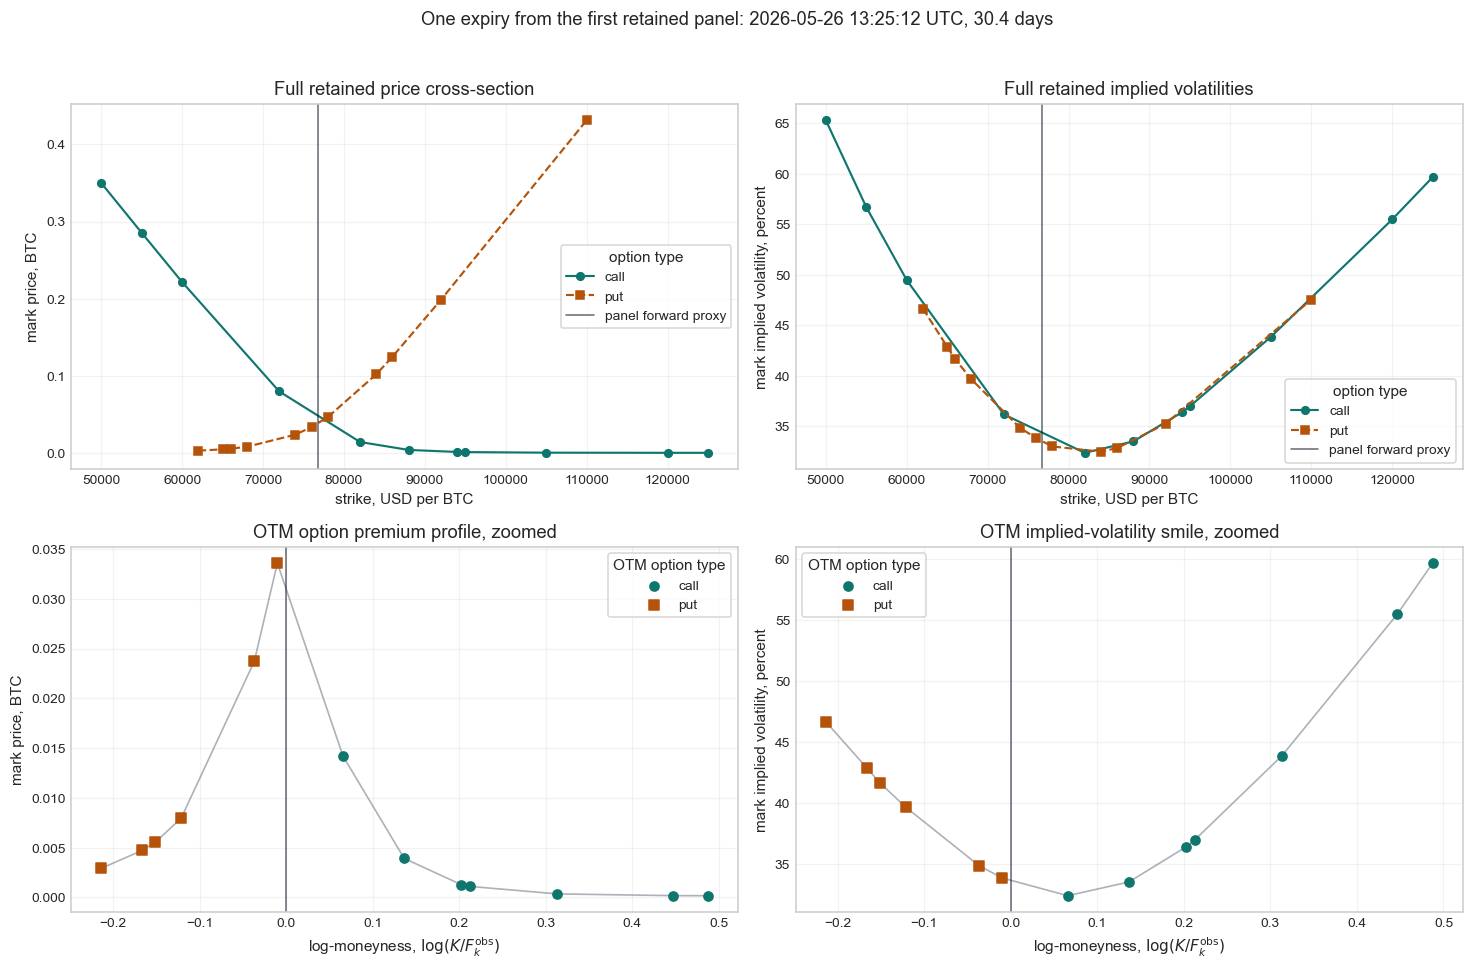

,option_type,n_quotes,expected_direction,monotonicity_check,convexity_check
0,call,11,decreasing in strike,passes,passes
1,put,11,increasing in strike,passes,passes


,capture_time_dt,expiry,F_obs_quote,F_obs_panel,maturity_days,strike,log_moneyness,option_type,is_otm,market_price,market_iv
110,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,50000.0,-0.428764,call,False,0.350118,0.6530
111,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,55000.0,-0.333454,call,False,0.285576,0.5670
112,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,60000.0,-0.246442,call,False,0.221634,0.4948
117,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,72000.0,-0.064121,call,False,0.079824,0.3619
121,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,82000.0,0.065932,call,True,0.014168,0.3239
124,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,88000.0,0.136550,call,True,0.003907,0.3352
126,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,94000.0,0.202508,call,True,0.001277,0.3639
127,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,95000.0,0.213090,call,True,0.001095,0.3700
128,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76864.66,76767.93,30.440825,105000.0,0.313173,call,True,0.000349,0.4386
130,2026-05-26 13:25:12.749879+00:00,2026-06-26T00:00:00+00:00,76862.45,76767.93,30.440825,120000.0,0.446705,call,True,0.000172,0.5549


In [66]:
PANEL_INDEX = 0
TARGET_MATURITY_DAYS = 30.0

example_time = selected_times[PANEL_INDEX]
example_panel = selected_options.loc[selected_options['capture_time_utc'].eq(example_time)].copy()
example_panel['maturity_days'] = 365.0 * example_panel['T_years']

expiry_summary = (
    example_panel.groupby('expiry', sort=True)
    .agg(maturity_days=('maturity_days', 'median'), n_quotes=('strike', 'size'))
    .sort_values('maturity_days')
    .reset_index()
)
chosen_idx = (expiry_summary['maturity_days'] - TARGET_MATURITY_DAYS).abs().idxmin()
chosen_expiry = expiry_summary.loc[chosen_idx, 'expiry']
chosen_maturity = expiry_summary.loc[chosen_idx, 'maturity_days']
smile_panel = example_panel.loc[example_panel['expiry'].eq(chosen_expiry)].copy()
panel_forward = float(smile_panel['F_obs_panel'].median())
smile_panel['is_otm'] = (
    (smile_panel['option_type'].eq('put') & (smile_panel['strike'] < panel_forward))
    | (smile_panel['option_type'].eq('call') & (smile_panel['strike'] >= panel_forward))
)
otm_panel = smile_panel.loc[smile_panel['is_otm']].copy()

display(expiry_summary)

markers = {'call': 'o', 'put': 's'}
linestyles = {'call': '-', 'put': '--'}
colors = {'call': '#0f766e', 'put': '#b45309'}

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.6))

for side in ['call', 'put']:
    side_panel = smile_panel.loc[smile_panel['option_type'].eq(side)].sort_values('strike')
    if side_panel.empty:
        continue

    axes[0, 0].plot(
        side_panel['strike'],
        side_panel['market_price'],
        color=colors[side],
        marker=markers[side],
        linestyle=linestyles[side],
        linewidth=1.4,
        markersize=5,
        label=side,
    )
    axes[0, 1].plot(
        side_panel['strike'],
        100.0 * side_panel['market_iv'],
        color=colors[side],
        marker=markers[side],
        linestyle=linestyles[side],
        linewidth=1.4,
        markersize=5,
        label=side,
    )

    otm_side_panel = otm_panel.loc[otm_panel['option_type'].eq(side)].sort_values('log_moneyness')
    if otm_side_panel.empty:
        continue
    axes[1, 0].scatter(
        otm_side_panel['log_moneyness'],
        otm_side_panel['market_price'],
        color=colors[side],
        marker=markers[side],
        s=36,
        label=side,
        zorder=2,
    )
    axes[1, 1].scatter(
        otm_side_panel['log_moneyness'],
        100.0 * otm_side_panel['market_iv'],
        color=colors[side],
        marker=markers[side],
        s=36,
        label=side,
        zorder=2,
    )

otm_sorted = otm_panel.sort_values('log_moneyness')
axes[1, 0].plot(
    otm_sorted['log_moneyness'],
    otm_sorted['market_price'],
    color='#6b7280',
    linewidth=1.1,
    alpha=0.55,
    zorder=1,
)
axes[1, 1].plot(
    otm_sorted['log_moneyness'],
    100.0 * otm_sorted['market_iv'],
    color='#6b7280',
    linewidth=1.1,
    alpha=0.55,
    zorder=1,
)

for ax in axes[0, :]:
    ax.axvline(panel_forward, color='#111827', linewidth=1.0, alpha=0.65, label='panel forward proxy')
    ax.set_xlabel('strike, USD per BTC')
    ax.grid(True, alpha=0.25)
    ax.legend(title='option type', loc='best', frameon=True)

for ax in axes[1, :]:
    ax.axvline(0.0, color='#111827', linewidth=1.0, alpha=0.65)
    ax.set_xlabel(r'log-moneyness, $\log(K / F_k^{\mathrm{obs}})$')
    ax.grid(True, alpha=0.25)
    ax.legend(title='OTM option type', loc='best', frameon=True)

axes[0, 0].set_title('Full retained price cross-section')
axes[0, 0].set_ylabel('mark price, BTC')
axes[0, 1].set_title('Full retained implied volatilities')
axes[0, 1].set_ylabel('mark implied volatility, percent')
axes[1, 0].set_title('OTM option premium profile, zoomed')
axes[1, 0].set_ylabel('mark price, BTC')
axes[1, 1].set_title('OTM implied-volatility smile, zoomed')
axes[1, 1].set_ylabel('mark implied volatility, percent')

panel_time = example_panel['capture_time_dt'].iloc[0].strftime('%Y-%m-%d %H:%M:%S UTC')
fig.suptitle(f'One expiry from the first retained panel: {panel_time}, {chosen_maturity:.1f} days', y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '00_example_panel_smiles.png', dpi=180, bbox_inches='tight')
plt.show()

def quick_strike_checks(data, side):
    side_data = data.loc[data['option_type'].eq(side)].sort_values('strike')
    strikes = side_data['strike'].to_numpy(dtype=float)
    prices = side_data['market_price'].to_numpy(dtype=float)
    if len(side_data) < 2:
        return {
            'option_type': side,
            'n_quotes': len(side_data),
            'monotonicity_check': 'not enough quotes',
            'convexity_check': 'not enough quotes',
        }

    diffs = np.diff(prices)
    if side == 'call':
        monotone_ok = bool(np.all(diffs <= 1e-10))
        expected_direction = 'decreasing in strike'
    else:
        monotone_ok = bool(np.all(diffs >= -1e-10))
        expected_direction = 'increasing in strike'

    slopes = np.diff(prices) / np.diff(strikes)
    convex_ok = bool(np.all(np.diff(slopes) >= -1e-10)) if len(slopes) >= 2 else True

    return {
        'option_type': side,
        'n_quotes': len(side_data),
        'expected_direction': expected_direction,
        'monotonicity_check': 'passes' if monotone_ok else 'fails',
        'convexity_check': 'passes' if convex_ok else 'fails',
    }


display(pd.DataFrame([quick_strike_checks(smile_panel, 'call'), quick_strike_checks(smile_panel, 'put')]))
display(
    smile_panel[
        ['capture_time_dt', 'expiry', 'F_obs_quote', 'F_obs_panel', 'maturity_days', 'strike', 'log_moneyness', 'option_type', 'is_otm', 'market_price', 'market_iv']
    ]
    .sort_values(['option_type', 'strike'])
)

*Saved figure:* `outputs/chapter2_data_descriptive_plots/figures/00_example_panel_smiles.png`


## 4. Compare the Same Expiry Before Subsampling

The previous figure shows the retained quotes used by the filter. This diagnostic compares the same expiry before and after panel subsampling, which makes the effect of the quote cap visible without changing the selected timestamp.


,stage,quotes,calls,puts
0,cleaned before cap-160 selection,62,31,31
1,retained after cap-160 selection,22,11,11
2,OTM retained subset,13,7,6


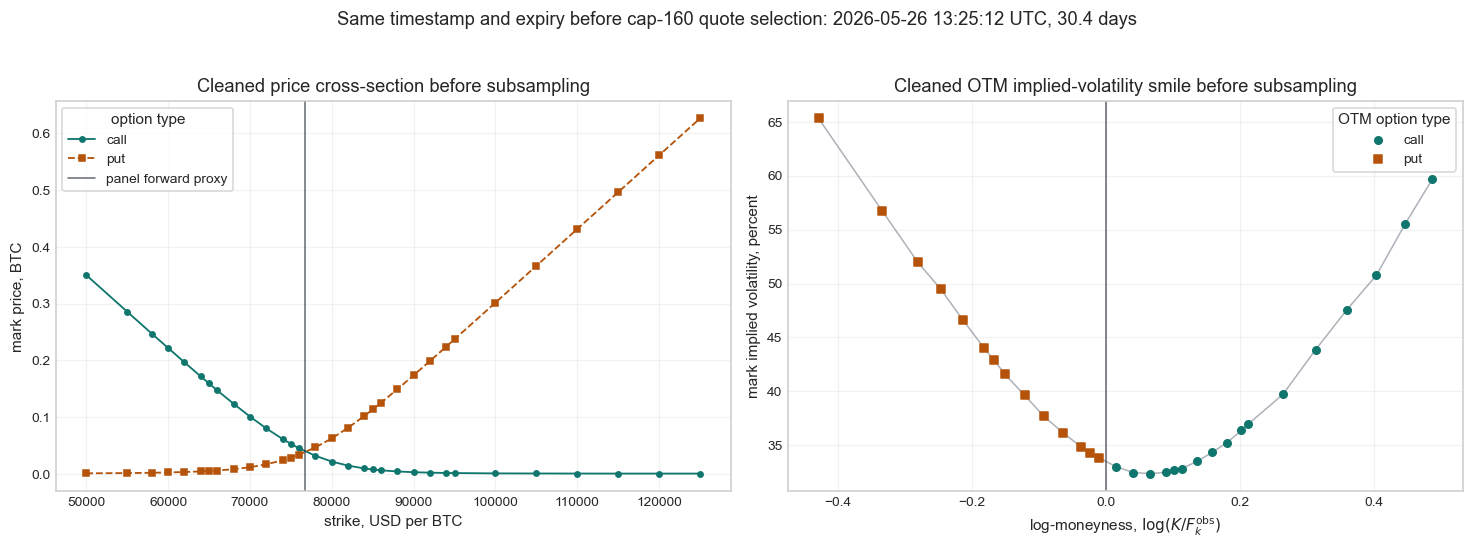

In [67]:
cleaned_example_panel = clean_options.loc[clean_options['capture_time_utc'].eq(example_time)].copy()
cleaned_smile_panel = cleaned_example_panel.loc[cleaned_example_panel['expiry'].eq(chosen_expiry)].copy()
cleaned_smile_panel['maturity_days'] = 365.0 * cleaned_smile_panel['T_years']
cleaned_smile_panel['F_obs_panel'] = panel_forward
cleaned_smile_panel['log_moneyness'] = np.log(cleaned_smile_panel['strike'] / cleaned_smile_panel['F_obs_panel'])
cleaned_smile_panel['is_otm'] = (
    (cleaned_smile_panel['option_type'].eq('put') & (cleaned_smile_panel['strike'] < panel_forward))
    | (cleaned_smile_panel['option_type'].eq('call') & (cleaned_smile_panel['strike'] >= panel_forward))
)
cleaned_otm_panel = cleaned_smile_panel.loc[cleaned_smile_panel['is_otm']].copy()

quote_count_summary = pd.DataFrame(
    [
        {
            'stage': 'cleaned before cap-160 selection',
            'quotes': len(cleaned_smile_panel),
            'calls': int(cleaned_smile_panel['option_type'].eq('call').sum()),
            'puts': int(cleaned_smile_panel['option_type'].eq('put').sum()),
        },
        {
            'stage': 'retained after cap-160 selection',
            'quotes': len(smile_panel),
            'calls': int(smile_panel['option_type'].eq('call').sum()),
            'puts': int(smile_panel['option_type'].eq('put').sum()),
        },
        {
            'stage': 'OTM retained subset',
            'quotes': len(otm_panel),
            'calls': int(otm_panel['option_type'].eq('call').sum()),
            'puts': int(otm_panel['option_type'].eq('put').sum()),
        },
    ]
)
display(quote_count_summary)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

for side in ['call', 'put']:
    side_panel = cleaned_smile_panel.loc[cleaned_smile_panel['option_type'].eq(side)].sort_values('strike')
    if side_panel.empty:
        continue
    axes[0].plot(
        side_panel['strike'],
        side_panel['market_price'],
        color=colors[side],
        marker=markers[side],
        linestyle=linestyles[side],
        linewidth=1.2,
        markersize=3.5,
        label=side,
    )

    otm_side_panel = cleaned_otm_panel.loc[cleaned_otm_panel['option_type'].eq(side)].sort_values('log_moneyness')
    if otm_side_panel.empty:
        continue
    axes[1].scatter(
        otm_side_panel['log_moneyness'],
        100.0 * otm_side_panel['market_iv'],
        color=colors[side],
        marker=markers[side],
        s=24,
        label=side,
        zorder=2,
    )

cleaned_otm_sorted = cleaned_otm_panel.sort_values('log_moneyness')
axes[1].plot(
    cleaned_otm_sorted['log_moneyness'],
    100.0 * cleaned_otm_sorted['market_iv'],
    color='#6b7280',
    linewidth=1.0,
    alpha=0.55,
    zorder=1,
)

axes[0].axvline(panel_forward, color='#111827', linewidth=1.0, alpha=0.65, label='panel forward proxy')
axes[0].set_title('Cleaned price cross-section before subsampling')
axes[0].set_xlabel('strike, USD per BTC')
axes[0].set_ylabel('mark price, BTC')
axes[0].legend(title='option type', loc='best', frameon=True)

axes[1].axvline(0.0, color='#111827', linewidth=1.0, alpha=0.65)
axes[1].set_title('Cleaned OTM implied-volatility smile before subsampling')
axes[1].set_xlabel(r'log-moneyness, $\log(K / F_k^{\mathrm{obs}})$')
axes[1].set_ylabel('mark implied volatility, percent')
axes[1].legend(title='OTM option type', loc='best', frameon=True)

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.suptitle(f'Same timestamp and expiry before cap-160 quote selection: {panel_time}, {chosen_maturity:.1f} days', y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '00b_cleaned_expiry_before_subsampling.png', dpi=180, bbox_inches='tight')
plt.show()

*Saved figure:* `outputs/chapter2_data_descriptive_plots/figures/00b_cleaned_expiry_before_subsampling.png`


## 5. Compare Multiple Expiry Slices Before and After Selection

The two figures below use the same timestamp and three representative maturities. They show how the full cleaned quote set is reduced to the capped panel used by the filter while preserving maturity and moneyness coverage.


,expiry,maturity_days,cleaned_quotes
0,2026-05-30T00:00:00+00:00,3.440825,50
1,2026-06-26T00:00:00+00:00,30.440825,62
2,2026-07-31T00:00:00+00:00,65.440825,92


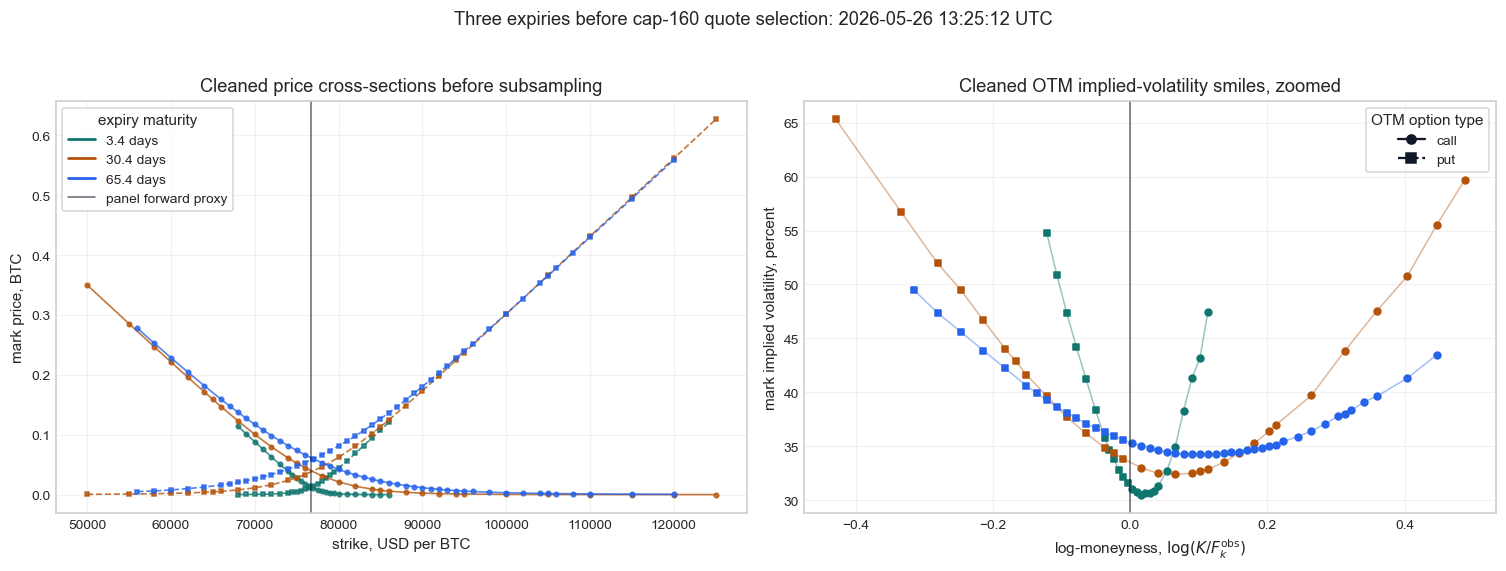

,expiry,maturity_days,n_quotes,n_quotes_after_cap
0,2026-05-30T00:00:00+00:00,3.440825,50,22
1,2026-06-26T00:00:00+00:00,30.440825,62,22
2,2026-07-31T00:00:00+00:00,65.440825,92,22


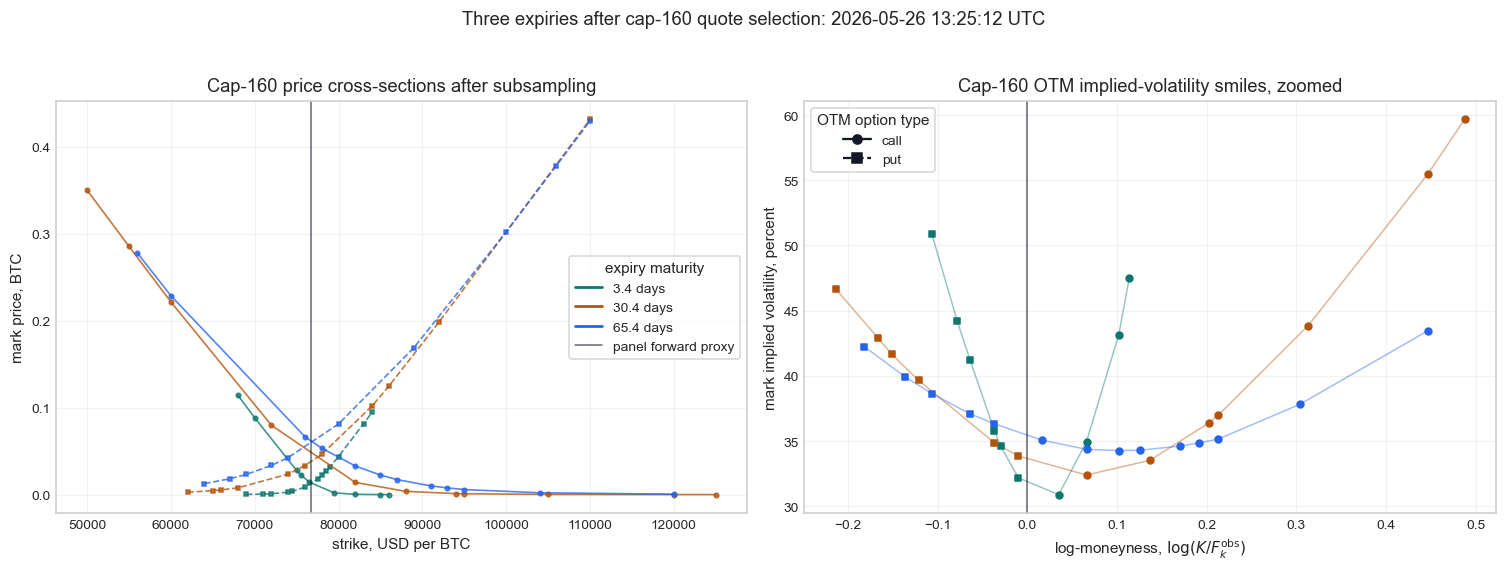

(<Figure size 1518x550 with 2 Axes>,
 array([<Axes: title={'center': 'Cap-160 price cross-sections after subsampling'}, xlabel='strike, USD per BTC', ylabel='mark price, BTC'>,
        <Axes: title={'center': 'Cap-160 OTM implied-volatility smiles, zoomed'}, xlabel='log-moneyness, $\\log(K / F_k^{\\mathrm{obs}})$', ylabel='mark implied volatility, percent'>],
       dtype=object))

In [68]:
MULTI_TARGET_MATURITIES_DAYS = [3.0, 30.0, 65.0]
CAP_OPTIONS_PER_TIMESTAMP_PANEL = 160

def choose_expiry_rows(panel, target_maturities):
    summary = (
        panel.groupby('expiry', sort=True)
        .agg(maturity_days=('T_years', lambda s: 365.0 * s.median()), n_quotes=('strike', 'size'))
        .sort_values('maturity_days')
        .reset_index()
    )

    available = summary.copy()
    rows = []
    for target_maturity in target_maturities:
        if available.empty:
            break
        nearest_idx = (available['maturity_days'] - target_maturity).abs().idxmin()
        rows.append(available.loc[nearest_idx])
        available = available.drop(index=nearest_idx)

    return pd.DataFrame(rows).sort_values('maturity_days').reset_index(drop=True)


def prepare_expiry_slice(panel, expiry, forward):
    out = panel.loc[panel['expiry'].eq(expiry)].copy()
    out['F_obs_panel'] = forward
    out['maturity_days'] = 365.0 * out['T_years']
    out['log_moneyness'] = np.log(out['strike'] / out['F_obs_panel'])
    out['is_otm'] = (
        (out['option_type'].eq('put') & (out['strike'] < forward))
        | (out['option_type'].eq('call') & (out['strike'] >= forward))
    )
    return out


def plot_price_and_otm_iv_panel(
    panel,
    expiry_rows,
    forward,
    *,
    left_title,
    right_title,
    suptitle,
    output_name,
):
    fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.0))
    expiry_palette = ['#0f766e', '#b45309', '#2563eb']
    expiry_handles = []

    for color, (_, row) in zip(expiry_palette, expiry_rows.iterrows()):
        expiry = row['expiry']
        maturity = row['maturity_days']
        expiry_panel = prepare_expiry_slice(panel, expiry, forward)
        if expiry_panel.empty:
            continue

        expiry_handles.append(
            plt.Line2D([0], [0], color=color, linewidth=1.8, label=f'{maturity:.1f} days')
        )

        for side in ['call', 'put']:
            side_panel = expiry_panel.loc[expiry_panel['option_type'].eq(side)].sort_values('strike')
            if side_panel.empty:
                continue
            axes[0].plot(
                side_panel['strike'],
                side_panel['market_price'],
                color=color,
                marker=markers[side],
                linestyle=linestyles[side],
                linewidth=1.1,
                markersize=3.0,
                alpha=0.78,
            )

        expiry_otm = expiry_panel.loc[expiry_panel['is_otm']].sort_values('log_moneyness')
        axes[1].plot(
            expiry_otm['log_moneyness'],
            100.0 * expiry_otm['market_iv'],
            color=color,
            linewidth=1.0,
            alpha=0.42,
            zorder=1,
        )

        for side in ['put', 'call']:
            side_points = expiry_otm.loc[expiry_otm['option_type'].eq(side)]
            axes[1].scatter(
                side_points['log_moneyness'],
                100.0 * side_points['market_iv'],
                color=color,
                marker=markers[side],
                s=20,
                zorder=2,
            )

    forward_handle = plt.Line2D([0], [0], color='#111827', linewidth=1.0, alpha=0.65, label='panel forward proxy')
    option_type_handles = [
        plt.Line2D([0], [0], color='#111827', marker='o', linestyle='-', label='call'),
        plt.Line2D([0], [0], color='#111827', marker='s', linestyle='--', label='put'),
    ]

    axes[0].axvline(forward, color='#111827', linewidth=1.0, alpha=0.65)
    axes[0].set_title(left_title)
    axes[0].set_xlabel('strike, USD per BTC')
    axes[0].set_ylabel('mark price, BTC')
    axes[0].legend(handles=expiry_handles + [forward_handle], title='expiry maturity', loc='best', frameon=True)

    axes[1].axvline(0.0, color='#111827', linewidth=1.0, alpha=0.65)
    axes[1].set_title(right_title)
    axes[1].set_xlabel(r'log-moneyness, $\log(K / F_k^{\mathrm{obs}})$')
    axes[1].set_ylabel('mark implied volatility, percent')
    axes[1].legend(handles=option_type_handles, title='OTM option type', loc='best', frameon=True)

    for ax in axes:
        ax.grid(True, alpha=0.25)

    fig.suptitle(suptitle, y=1.03)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / output_name, dpi=180, bbox_inches='tight')
    plt.show()
    return fig, axes


cleaned_example_panel = clean_options.loc[clean_options['capture_time_utc'].eq(example_time)].copy()
cleaned_panel_forward = float(cleaned_example_panel['F_obs_quote'].median())
selected_expiry_summary = choose_expiry_rows(cleaned_example_panel, MULTI_TARGET_MATURITIES_DAYS)
display(selected_expiry_summary.rename(columns={'n_quotes': 'cleaned_quotes'}))

plot_price_and_otm_iv_panel(
    cleaned_example_panel,
    selected_expiry_summary,
    cleaned_panel_forward,
    left_title='Cleaned price cross-sections before subsampling',
    right_title='Cleaned OTM implied-volatility smiles, zoomed',
    suptitle=f'Three expiries before cap-160 quote selection: {panel_time}',
    output_name='00c_three_cleaned_price_otm_iv_before_subsampling.png',
)

cap160_example_panel = subsample_panel(cleaned_example_panel, CAP_OPTIONS_PER_TIMESTAMP_PANEL).copy()
cap160_panel_forward = float(cap160_example_panel['F_obs_quote'].median())
cap160_counts = (
    cap160_example_panel.groupby('expiry', sort=True)
    .agg(n_quotes_after_cap=('strike', 'size'))
    .reset_index()
)
cap160_expiry_summary = selected_expiry_summary.merge(cap160_counts, on='expiry', how='left')
display(cap160_expiry_summary)

plot_price_and_otm_iv_panel(
    cap160_example_panel,
    selected_expiry_summary,
    cap160_panel_forward,
    left_title='Cap-160 price cross-sections after subsampling',
    right_title='Cap-160 OTM implied-volatility smiles, zoomed',
    suptitle=f'Three expiries after cap-160 quote selection: {panel_time}',
    output_name='00d_three_cap160_price_otm_iv_after_subsampling.png',
)

*Saved figures:* `outputs/chapter2_data_descriptive_plots/figures/00c_three_expiry_slices_before_subsampling.png` and `outputs/chapter2_data_descriptive_plots/figures/00d_three_expiry_slices_after_selection.png`


## 6. Plot 1: Forward Proxy and Implied-Volatility Level

This plot gives a compact view of the market environment over the selected window.


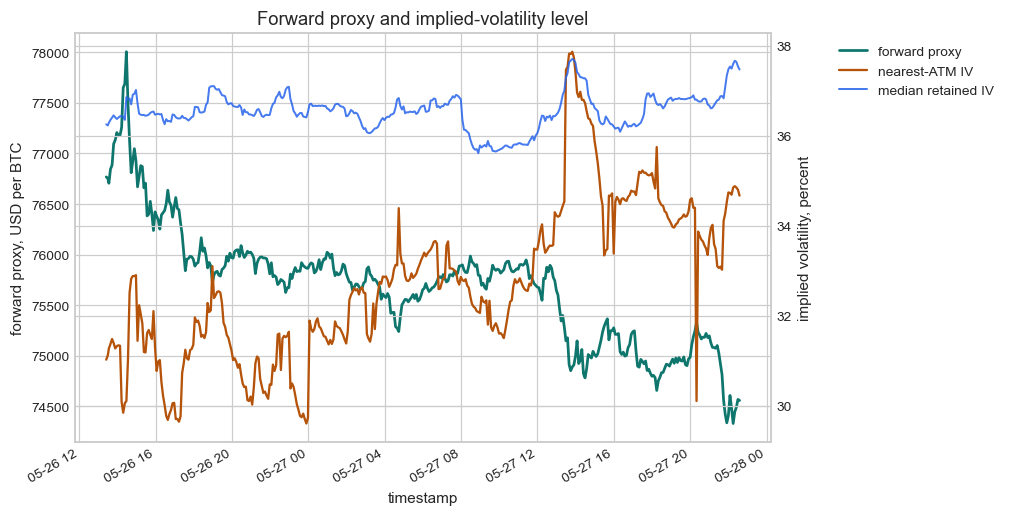

In [69]:
fig, ax_forward = plt.subplots(figsize=(11, 4.8))

ax_forward.plot(
    panel_summary['capture_time_dt'],
    panel_summary['F_obs'],
    color='#0f766e',
    linewidth=1.8,
    label='forward proxy',
)
ax_forward.set_title('Forward proxy and implied-volatility level')
ax_forward.set_ylabel('forward proxy, USD per BTC')
ax_forward.set_xlabel('timestamp')

ax_iv = ax_forward.twinx()
if panel_summary['atm_iv'].notna().any():
    ax_iv.plot(
        panel_summary['capture_time_dt'],
        100.0 * panel_summary['atm_iv'],
        color='#b45309',
        linewidth=1.5,
        label='nearest-ATM IV',
    )
if panel_summary['median_iv'].notna().any():
    ax_iv.plot(
        panel_summary['capture_time_dt'],
        100.0 * panel_summary['median_iv'],
        color='#2563eb',
        linewidth=1.3,
        alpha=0.85,
        label='median retained IV',
    )
ax_iv.set_ylabel('implied volatility, percent')

lines, labels = ax_forward.get_legend_handles_labels()
lines2, labels2 = ax_iv.get_legend_handles_labels()
ax_forward.legend(
    lines + lines2,
    labels + labels2,
    loc='upper left',
    bbox_to_anchor=(1.08, 1.0),
    frameon=False,
)
fig.autofmt_xdate()
fig.tight_layout(rect=[0.0, 0.0, 0.86, 1.0])
fig.savefig(FIGURE_DIR / '01_forward_and_iv.png', dpi=180, bbox_inches='tight')
plt.show()

*Saved figure:* `outputs/chapter2_data_descriptive_plots/figures/01_forward_and_iv.png`


## 7. Plot 2: Panel Composition Through Time

This plot shows how many quotes and expiries remain after the baseline cleaning and timestamp-level quote cap.


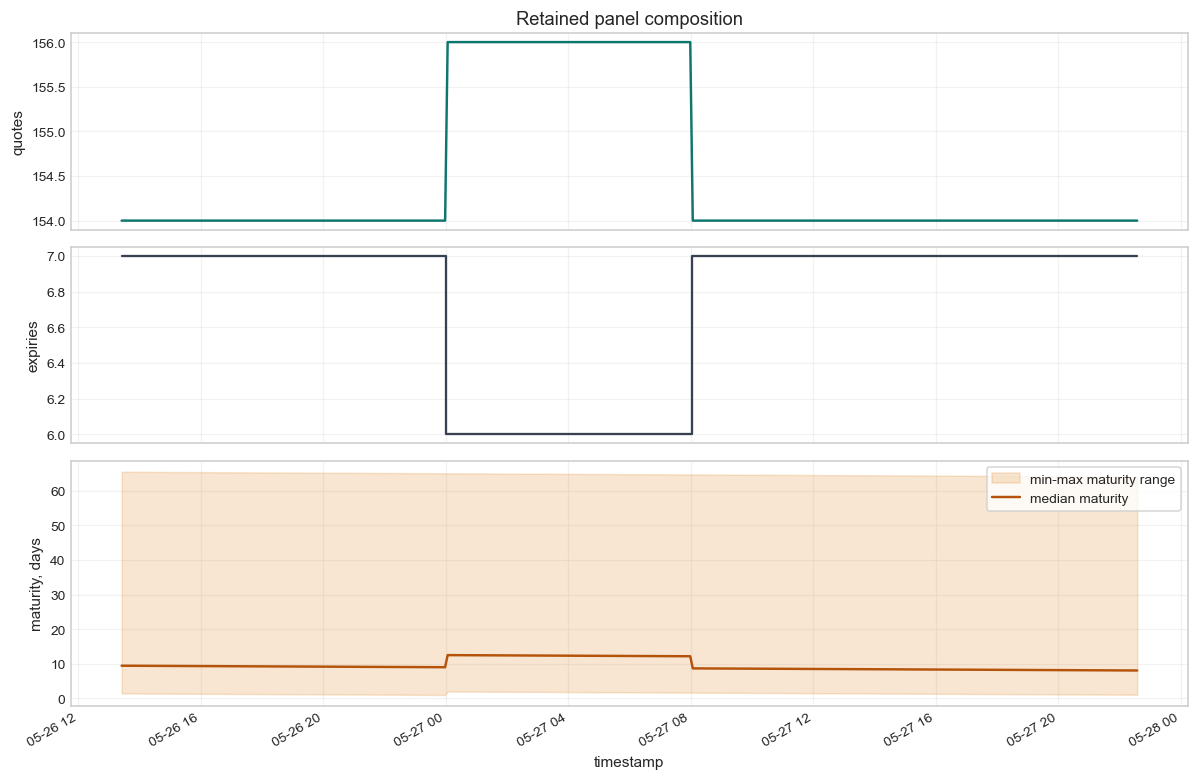

In [70]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(11, 7.2),
    sharex=True,
    gridspec_kw={'height_ratios': [1.0, 1.0, 1.25]},
)

axes[0].plot(panel_summary['capture_time_dt'], panel_summary['n_quotes'], color='#0f766e', linewidth=1.6)
axes[0].set_ylabel('quotes')
axes[0].set_title('Retained panel composition')

axes[1].step(panel_summary['capture_time_dt'], panel_summary['n_expiries'], where='mid', color='#374151', linewidth=1.5)
axes[1].set_ylabel('expiries')

axes[2].fill_between(
    panel_summary['capture_time_dt'],
    panel_summary['min_maturity_days'],
    panel_summary['max_maturity_days'],
    color='#d97706',
    alpha=0.18,
    label='min-max maturity range',
)
axes[2].plot(
    panel_summary['capture_time_dt'],
    panel_summary['median_maturity_days'],
    color='#b45309',
    linewidth=1.6,
    label='median maturity',
)
axes[2].set_ylabel('maturity, days')
axes[2].set_xlabel('timestamp')
axes[2].legend(loc='upper right', frameon=True)

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURE_DIR / '02_panel_composition.png', dpi=180, bbox_inches='tight')
plt.show()

*Saved figure:* `outputs/chapter2_data_descriptive_plots/figures/02_panel_composition.png`


## 8. Plot 3: Maturity and Moneyness Coverage

This plot shows where the retained quotes sit across maturities and log-moneyness.


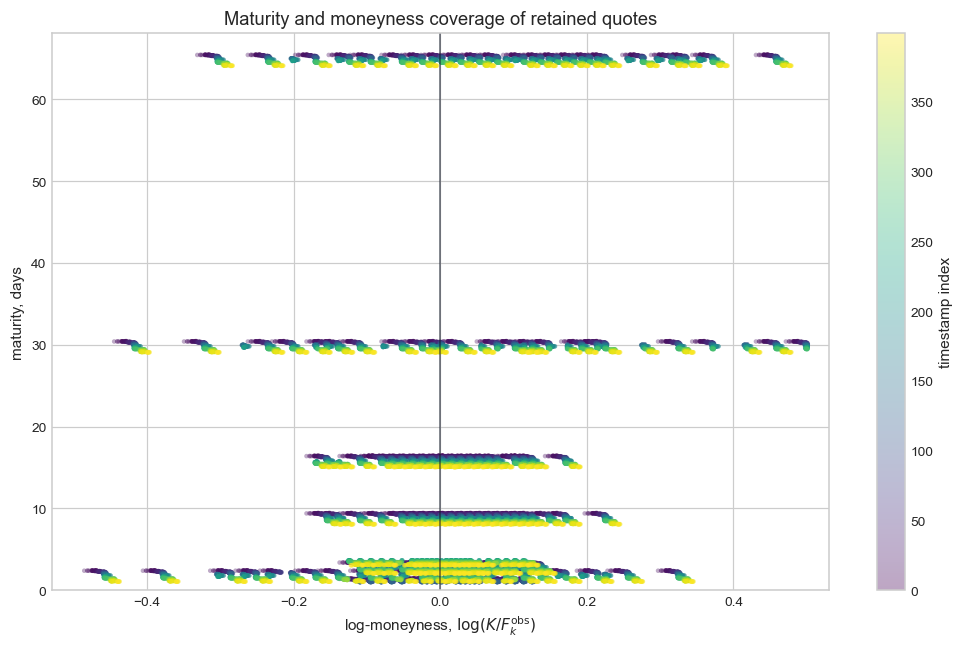

In [71]:
coverage = selected_options.copy()
coverage['maturity_days'] = 365.0 * coverage['T_years']

fig, ax = plt.subplots(figsize=(9.5, 6.0))
scatter = ax.scatter(
    coverage['log_moneyness'],
    coverage['maturity_days'],
    c=coverage['t_index'],
    cmap='viridis',
    s=9,
    alpha=0.35,
    edgecolors='none',
)
ax.axvline(0.0, color='#111827', linewidth=1.0, alpha=0.65)
ax.set_title('Maturity and moneyness coverage of retained quotes')
ax.set_xlabel(r'log-moneyness, $\log(K / F_k^{\mathrm{obs}})$')
ax.set_ylabel('maturity, days')
ax.set_xlim(-MAX_ABS_LOG_MONEYNESS - 0.03, MAX_ABS_LOG_MONEYNESS + 0.03)
ax.set_ylim(0.0, max(5.0, coverage['maturity_days'].max() * 1.04))
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('timestamp index')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_maturity_moneyness_coverage.png', dpi=180, bbox_inches='tight')
plt.show()

*Saved figure:* `outputs/chapter2_data_descriptive_plots/figures/03_maturity_moneyness_coverage.png`
